In [1]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# 03_rq1.py
# Purpose of Script: Get RQ1 Calculations & Visualisations
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initialization ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Google Drive
#~~~~~~~~~~~~~~~~~~~~~~~~~~
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [89]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Libraries
#~~~~~~~~~~~~~~~~~~~~~~~~~~
import numpy as np
import pandas as pd
import gc
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr
from matplotlib.colors import LinearSegmentedColormap

In [3]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Print Versions
#~~~~~~~~~~~~~~~~~~~~~~~~~~
print(f"Numpy version = {np.__version__}")
print(f"Pandas version = {pd.__version__}")
print(f"DuckDB version = {duckdb.__version__}")
print(f"Seaborn version = {sns.__version__}")

Numpy version = 2.0.2
Pandas version = 2.2.2
DuckDB version = 1.3.2
Seaborn version = 0.13.2


In [4]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initiate Duck Connection
#~~~~~~~~~~~~~~~~~~~~~~~~~~
con = duckdb.connect()

#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Define Input/Output Paths
#~~~~~~~~~~~~~~~~~~~~~~~~~~
### Input
path_samp = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/01_final_data/03_samples/"
path_out = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/03_outputs/"

In [5]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Quantitative Synthetic ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import
df = con.execute(f""" select * from '{path_samp}rq1_final.parquet' """).df()

# Filter Sample Only for Observation Period (Sample Collection Added Dates with 0 Entries)
df = df[df["date"] <= "2026-05-31 00:00:00"]

In [6]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Cut Down & Format
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Identify Relevant Columns
cols_to_extract = ['platform','date','total_sor_entries',
                   'content_type_image','content_type_product',
                   'content_type_synthetic_media',
                   'content_type_text','content_type_video','content_type_other',
                   'content_type_audio', 'i_and_t_content_type', 'i_and_t_and_v_content_type',
                   't_and_i_content_type','i_and_v_content_type',
                   'content_type_multiple', 'v_and_i_content_type',
                   'CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type',
                   'CONTENT_TYPE_IMAGE,CONTENT_TYPE_VIDEO_content_type',
                   'CONTENT_TYPE_VIDEO,CONTENT_TYPE_IMAGE_content_type']

df_quant = df[cols_to_extract].copy()

# Capitalize Platform String
df_quant.loc[:, "platform"] = df_quant["platform"].str.capitalize()


# Amalgamate content_type columns that are mixed
sum_cols = ['i_and_t_content_type', 'i_and_t_and_v_content_type',
            't_and_i_content_type','i_and_v_content_type','content_type_multiple',
            'v_and_i_content_type',
            'CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type',
            'CONTENT_TYPE_IMAGE,CONTENT_TYPE_VIDEO_content_type',
            'CONTENT_TYPE_VIDEO,CONTENT_TYPE_IMAGE_content_type']

df_quant["content_type_mixed"] = df_quant[sum_cols].sum(axis=1)

df_quant.drop(columns=sum_cols, inplace=True)

In [7]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Duplicates ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_dup = pd.read_csv(f"{path_out}01c_dq_1_duplicate_entries.csv")

# Identify Relevant Columns
cols_to_extract = ['platform','date','total_sor_entries',
                   'content_type_image',
                   'content_type_synthetic_media',
                   'content_type_video','content_type_other']

# Cut Down
df_dup = df_dup[cols_to_extract].copy()

# Fill NA
df_dup = df_dup.fillna(0)

# Capitalize
df_dup["platform"] = df_dup["platform"].str.capitalize()

# Alter Colnames
df_dup.columns = df_dup.columns + '_dup'

### Format DateTime
df_dup["date_dup"] = pd.to_datetime(df_dup["date_dup"])

In [8]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Qualitative Synthetic ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Tiktok
df_syn_tiktok = con.execute(f""" select date, count(*) as qual_syn_sor_entries
                                 from read_parquet('{path_out}02_rq1_qual_14_tiktok_*.parquet')
                                 group by date""").df()

df_syn_tiktok["platform"] = "tiktok"

# Format
df_syn_tiktok["date"] = pd.to_datetime(df_syn_tiktok["date"])
df_syn_tiktok["platform"] = df_syn_tiktok["platform"].str.capitalize()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Monthly User Numbers - Using Per Million
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_users = pd.read_csv(f"{path_out}00_average_monthly_users_clean.csv").reset_index(drop=True)
df_users = df_users[["platform","date","users"]]
df_users["date"] = pd.to_datetime(df_users["date"])
df_users["platform"] = df_users["platform"].str.capitalize()
df_users["users_million"] = df_users["users"]/1000000

In [10]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Join All Data ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#### Quant & Qual
df = df_quant.merge(df_syn_tiktok,
                    how="left",
                    left_on=["platform","date"],
                    right_on=["platform","date"])

### For entries with synthetic 0 SORs
df["qual_syn_sor_entries"] = df["qual_syn_sor_entries"].fillna(0)

### Format DateTime
df["date"] = pd.to_datetime(df["date"])

##### Join Duplicates
df = df.merge(df_dup,
              how="left",
              left_on=["platform","date"],
              right_on=["platform_dup","date_dup"]).drop(columns=["platform_dup","date_dup"])

##### Fill NA
df = df.fillna(0)

#### Join Monthly Users
df = df.merge(df_users, how="left", on=["platform","date"])

In [11]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Remove Duplicates ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Remove
df["total_sor_entries_minus_dup"] = df["total_sor_entries"] - df["total_sor_entries_dup"]
df["content_type_image_minus_dup"] = df["content_type_image"] - df["content_type_image_dup"]
df["content_type_synthetic_media_minus_dup"] = df["content_type_synthetic_media"] - df["content_type_synthetic_media_dup"]
df["content_type_video_minus_dup"] = df["content_type_video"] - df["content_type_video_dup"]
df["content_type_other_minus_dup"] = df["content_type_other"] - df["content_type_other_dup"]

In [12]:
# Replace Old Columns
df["total_sor_entries"] = df["total_sor_entries_minus_dup"]
df["content_type_image"] = df["content_type_image_minus_dup"]
df["content_type_synthetic_media"] = df["content_type_synthetic_media_minus_dup"]
df["content_type_video"] = df["content_type_video_minus_dup"]
df["content_type_other"] = df["content_type_other_minus_dup"]

In [13]:
# Remove Columns - Minus & Duplicates
df = df.drop(columns=["total_sor_entries_minus_dup","content_type_image_minus_dup",
                      "content_type_synthetic_media_minus_dup","content_type_video_minus_dup",
                      "content_type_other_minus_dup"])

df = df.drop(columns=["total_sor_entries_dup","content_type_image_dup",
                      "content_type_synthetic_media_dup","content_type_video_dup",
                      "content_type_other_dup"])

In [14]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Content Type Composition ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Quant - Calculate Totals for All Platforms
content_cols = ['total_sor_entries',
                'content_type_image','content_type_product',
                'content_type_synthetic_media','content_type_text',
                'content_type_video','content_type_audio',
                'content_type_other',
                'content_type_mixed']

# Note - Mixed contains only i, v and t

overall = (df[content_cols].sum().to_frame().T)

# Provide Name
overall.insert(0, "platform", "All Platforms")

In [15]:
### Quant - Calculate Totals per Platform
platform_overall = (df.groupby("platform", as_index=False)[content_cols].sum())

# Join Overall and Platform
overall = pd.concat([overall, platform_overall])

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Content Type Composition - Export ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
overall.to_csv(f"{path_out}03_rq1_1_content_type_composition.csv")

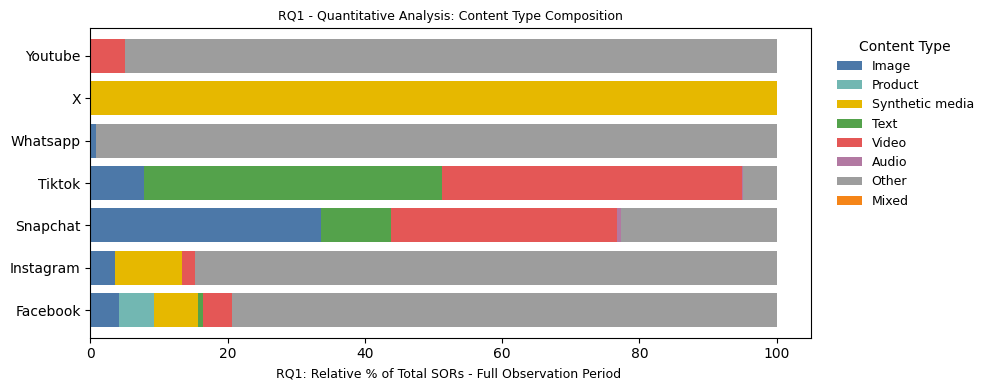

In [16]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Content Type Composition Plot ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Calculate Relative Amounts of Content Type
content_cols = [c for c in platform_overall.columns if c.startswith("content_type_")]

platform_rel = (platform_overall[content_cols].div(platform_overall["total_sor_entries"], axis=0))

### Add Platform Names
platform_rel.index = platform_overall["platform"]

### Alter Column Names
platform_rel.columns = (platform_rel.columns
                        .str.replace('content_type_',"",regex=False)
                        .str.replace("_"," ")
                        .str.capitalize())

### Visualise
# Define Colours
colours = ["#4C78A8", "#72B7B2", "#E6B800", "#54A24B", "#E45756",
           "#B279A2", "#9D9D9D", "#F58518"]

ax = (platform_rel * 100).plot(kind="barh",
                               stacked=True,
                               figsize=(10, 4),
                               width=0.8,
                               color=colours)

ax.set_xlabel("RQ1: Relative % of Total SORs - Full Observation Period ", fontsize=9)
ax.set_ylabel("")
ax.set_title("RQ1 - Quantitative Analysis: Content Type Composition", fontsize=9)
ax.legend(title="Content Type", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()

plt.savefig(f"{path_out}03_rq1_2_content_type_stacked_barchart.pdf",
            format="pdf", dpi=300, bbox_inches="tight")

In [17]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Synthetic Media Prevalence ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Platform Level Synthetic Media
platform_summary = (df.groupby("platform", as_index=False)
                    .agg({"total_sor_entries": "sum",
                          "content_type_synthetic_media": "sum",
                          "qual_syn_sor_entries": "sum"})).reset_index()

### Calculate Average Users
users = (df.groupby("platform")["users_million"]
         .apply(lambda x: x.drop_duplicates().mean())
         .reset_index(name="users_million")).round(2)

### Merge Users
platform_summary = platform_summary.merge(users, on="platform").reset_index(drop=True)

### Derived Columns
#### Platform Moderation Intensity
platform_summary["moderation_intensity"] = (platform_summary["total_sor_entries"] / platform_summary["users_million"]).round(2)

#### Syn Rel to Totals
platform_summary["quant_syn_rel_to_total_perc"] = ((platform_summary["content_type_synthetic_media"] / platform_summary["total_sor_entries"])*100).round(2)
platform_summary["qual_syn_rel_to_total_perc"] = ((platform_summary["qual_syn_sor_entries"] / platform_summary["total_sor_entries"])*100).round(2)

#### Syn Rel to Users
platform_summary["quant_syn_rel_to_users"] = (platform_summary["content_type_synthetic_media"] / platform_summary["users_million"]).round(2)
platform_summary["qual_syn_rel_to_users"] = (platform_summary["qual_syn_sor_entries"] / platform_summary["users_million"]).round(2)

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Synthetic Media Prevalence - Export ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
platform_summary.to_csv(f"{path_out}03_rq1_3_synthetic_media_prevalence.csv")

In [18]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Synthetic Media Prevalence - All Platforms ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Platform Summary
platform_summary_all = (df.groupby("platform", as_index=False)
                        .agg(total_sors=("total_sor_entries", "sum"),
                             content_type_synthetic_media=("content_type_synthetic_media", "sum"),
                             qual_syn_sor_entries=("qual_syn_sor_entries", "sum")))

### Overall
overall = pd.DataFrame({"platform": ["All Platforms"], "total_sors": [df["total_sor_entries"].sum()],
                        "content_type_synthetic_media": [df["content_type_synthetic_media"].sum()],
                        "qual_syn_sor_entries": [df["qual_syn_sor_entries"].sum()]})

### Export
overall.to_csv(f"{path_out}03_rq1_4_synthetic_media_prevalence_all_platforms.csv")

In [19]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Synthetic Media Time Series Analysis Daily Prevalence ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Copy Base Table - Create Amalgamated Synthetic Column
df_time = df.copy()
df_time["syn_all"] = np.select([df_time["platform"].eq("Tiktok")],
                               [df_time["qual_syn_sor_entries"]],
                               default=df_time["content_type_synthetic_media"])

### Cut Down
df_time = df_time[["platform","date","total_sor_entries","syn_all",
                   "users","users_million"]]

### Synthetic Prevalece Relative to SORs
df_time["syn_rel_to_total_perc"] = (df_time["syn_all"]/df_time["total_sor_entries"] * 100)

In [20]:
### Summary Statistics - Mean, SD, Min, Max - Relative to Total SORs Submitted
#### Platform Level
summary_stat = (df_time.groupby("platform", as_index=False)
                .agg(mean = ("syn_rel_to_total_perc", "mean"),
                     sd = ("syn_rel_to_total_perc", "std"),
                     min = ("syn_rel_to_total_perc", "min"),
                     max = ("syn_rel_to_total_perc", "max")))

# CV
summary_stat["cv"] = (summary_stat["sd"]/summary_stat["mean"])

# Round & Fill
summary_stat = summary_stat.round(3)
summary_stat = summary_stat.fillna(0)

#### Overall Level
summary_stat_all = pd.DataFrame({"platform" : "All Platforms",
                                 "mean": [df_time["syn_rel_to_total_perc"].mean()],
                                 "sd": [df_time["syn_rel_to_total_perc"].std()],
                                 "min": [df_time["syn_rel_to_total_perc"].min()],
                                 "max": [df_time["syn_rel_to_total_perc"].max()]})
# CV
summary_stat_all["cv"] = (summary_stat_all["sd"]/summary_stat_all["mean"])

# Round & Fill
summary_stat_all = summary_stat_all.round(3)
summary_stat_all = summary_stat_all.fillna(0)

# Concatenate
summary_stat = pd.concat([summary_stat, summary_stat_all])

# Export
summary_stat.to_csv(f"{path_out}03_rq1_5_synth_prev_rolling_statistics.csv")

In [21]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Synthetic Media Time Series Analysis Rolling Averages ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#### Sort Order
df_time = df_time.sort_values(["platform", "date"])

#### Calculate Roll - Nominal Amount
df_time["roll_syn_nominal"] = (df_time.groupby("platform")["syn_all"]
                               .rolling(30, min_periods=1)
                               .mean()
                               .reset_index(drop=True)).round(3)

#### Calculate Roll - Prevalence
df_time["roll_syn_prev"] = (df_time.groupby("platform")["syn_rel_to_total_perc"]
                               .rolling(30, min_periods=1)
                               .mean()
                               .reset_index(drop=True)).round(3)

#### Calculate Roll - Total SOR Entries
df_time["roll_all"] = (df_time.groupby("platform")["total_sor_entries"]
                               .rolling(30, min_periods=1)
                               .mean()
                               .reset_index(drop=True)).round(3)

#### Export for Use in RQ3
df_time.to_csv(f"{path_out}03_rq1_xx_rq1_plot_base_sample.csv")

In [121]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Correlation Analysis
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_corr = df_time.copy()

# Alter Platform Name
df_corr["platform"] = df_corr["platform"].replace("Tiktok", "TikTok")

# Cut Down DataFrame
df_corr = df_corr[["platform","date","roll_syn_prev"]]

# Restrict to Platforms with Synthetic
df_corr = df_corr[(df_corr["platform"] == "Facebook") | (df_corr["platform"] == "Instagram")
| (df_corr["platform"] == "TikTok") | (df_corr["platform"] == "X") ]

# Pivot
df_corr = df_corr.pivot(index="date", columns="platform", values="roll_syn_prev")

platforms = df_corr.columns

r_matrix = pd.DataFrame(index=platforms, columns=platforms, dtype=float)
p_matrix = pd.DataFrame(index=platforms, columns=platforms, dtype=float)

for i in platforms:
    for j in platforms:

        # Accomodate for missing TikTok Observations
        pair = df_corr[[i, j]].dropna()

        # Accomodate for identical platforms, pmcc = 1, p-value = 0
        if i == j:
          r = 1.0
          p = 0.0

        # Calculate Correlation
        elif len(pair) > 2:
          r, p = pearsonr(pair[i], pair[j])

        else:
          r, p = np.nan, np.nan

        # Form Correlation & p-value matrices
        r_matrix.loc[i, j] = r
        p_matrix.loc[i, j] = p



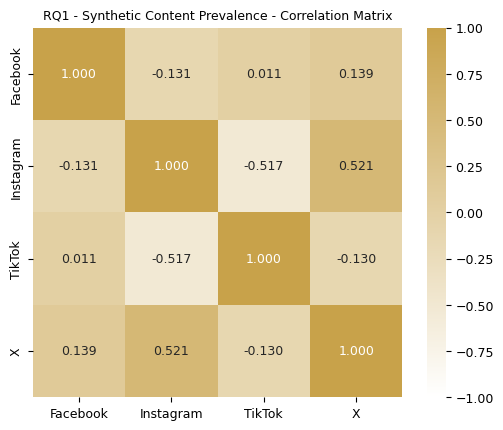

In [124]:
# Visualisaing Raw Correlation Coefficients
### Set Colours
colors = LinearSegmentedColormap.from_list("white_gold", ["white", "#C8A24A"])

sns.heatmap(r_matrix, annot=True, annot_kws={"size": 9}, cmap=colors,
            vmin=-1, vmax=1, center=0, square=True, linewidths=0,
            fmt=".3f")

ax = plt.gca()

# Set Labels
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)
ax.set_title("RQ1 - Synthetic Content Prevalence - Correlation Matrix",
             fontsize=9)

# Format Colourbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)

# Save Figure
plt.savefig(f"{path_out}03_rq1_5b_30day_roll_correlation.pdf",
            format="pdf", dpi=300, bbox_inches="tight")

plt.show()

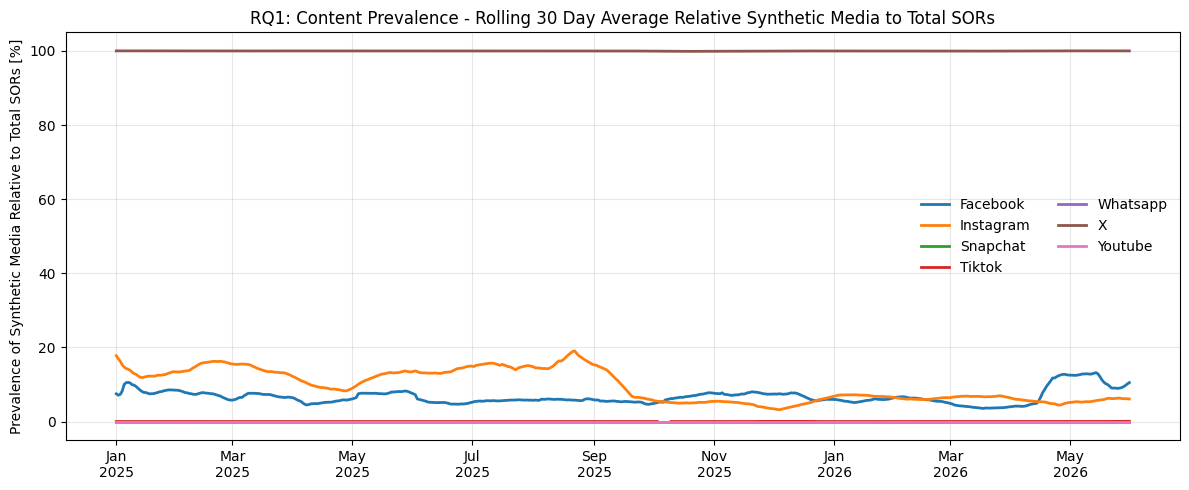

In [26]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Analysis & Visualisation: Synthetic Media Time Series Analysis Rolling Averages Visualisation ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Rolling Prevalance Graph
#### Synthetic relative to total over time
fig, ax = plt.subplots(figsize=(12,5))

for platform, d in df_time.groupby("platform"):
  ax.plot(d["date"], d["roll_syn_prev"],
          linewidth=2, label=platform)

ax.set_xlabel("")
ax.set_ylabel("Prevalence of Synthetic Media Relative to Total SORs [%]")
ax.set_title("RQ1: Content Prevalence - Rolling 30 Day Average Relative Synthetic Media to Total SORs")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(f"{path_out}03_rq1_6a_30day_roll_rel_synth_to_total.pdf",
            format="pdf", dpi=300, bbox_inches="tight")

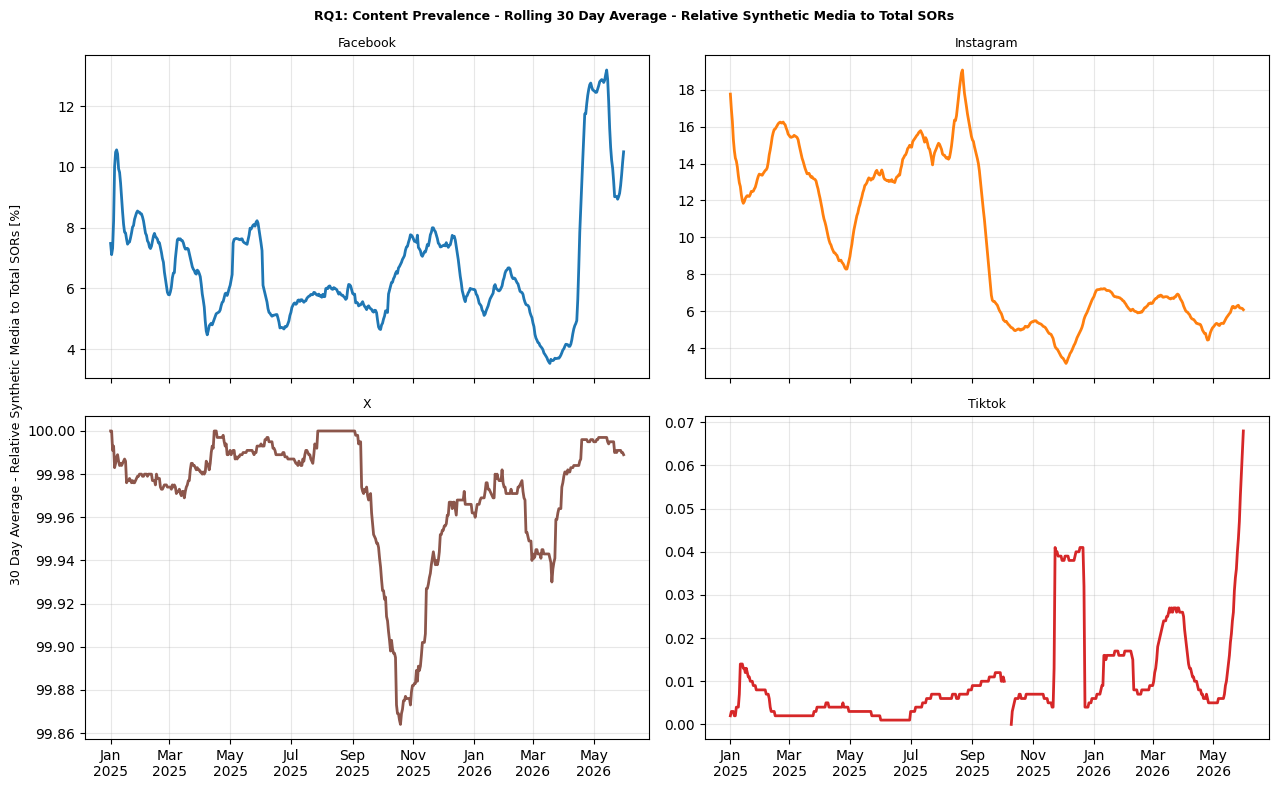

In [23]:
### Rolling Prevalance Graph - One Panel Per Platform
#### Synthetic relative to total over time - One Panel Per Platform

# Define Platforms
platform_order = ["Facebook","Instagram","X","Tiktok"]

# Define Colours
colours = {"Facebook": "tab:blue", "Instagram": "tab:orange",
           "X": "tab:brown","Tiktok": "tab:red"}

fig, axes = plt.subplots(2, 2, figsize=(13,8), sharex=True, sharey=False)

axes = axes.flatten()

for ax, platform in zip(axes, platform_order):

  d = df_time[df_time["platform"] == platform]

  ax.plot(d["date"], d["roll_syn_prev"], color=colours[platform], linewidth=2)

  ax.set_title(platform.capitalize(), fontsize=9)
  ax.grid(alpha=0.3)

  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

fig.supylabel("30 Day Average - Relative Synthetic Media to Total SORs [%]",
              fontsize=9)
fig.suptitle("RQ1: Content Prevalence - Rolling 30 Day Average - Relative Synthetic Media to Total SORs",
             fontsize=9, fontweight="bold")

plt.tight_layout()

plt.savefig(f"{path_out}03_rq1_6_30day_roll_rel_synth_to_total.pdf",
            format="pdf", dpi=300, bbox_inches="tight")


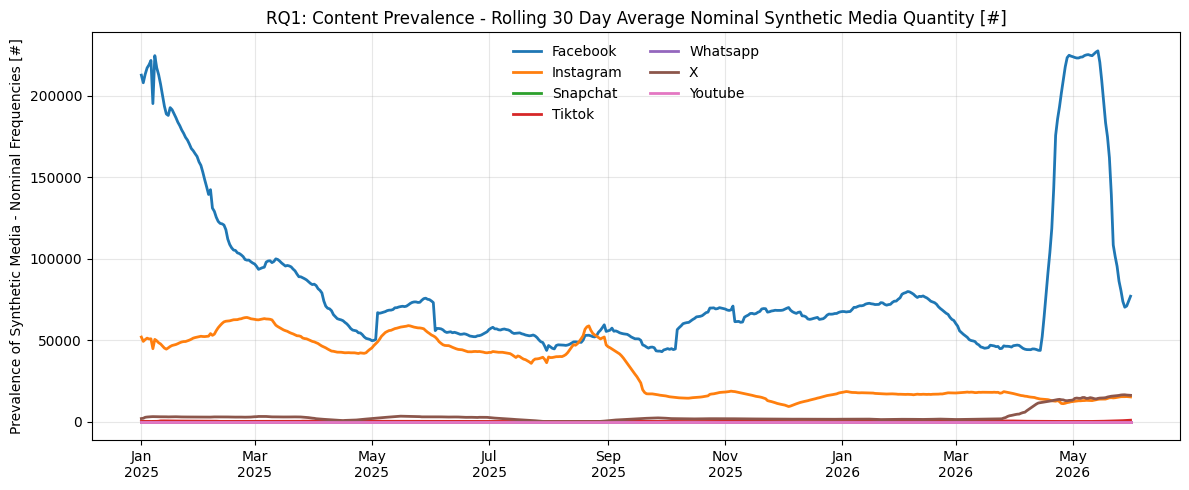

In [24]:
### Rolling Counts - Appendix
#### Nominal Rolling Amounts
fig, ax = plt.subplots(figsize=(12,5))

for platform, d in df_time.groupby("platform"):
  ax.plot(d["date"], d["roll_syn_nominal"],
          linewidth=2, label=platform)

ax.set_xlabel("")
ax.set_ylabel("Prevalence of Synthetic Media - Nominal Frequencies [#]")
ax.set_title("RQ1: Content Prevalence - Rolling 30 Day Average Nominal Synthetic Media Quantity [#]")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(f"{path_out}03_rq1_7_30day_roll_nominal_synth.pdf",
            format="pdf", dpi=300, bbox_inches="tight")

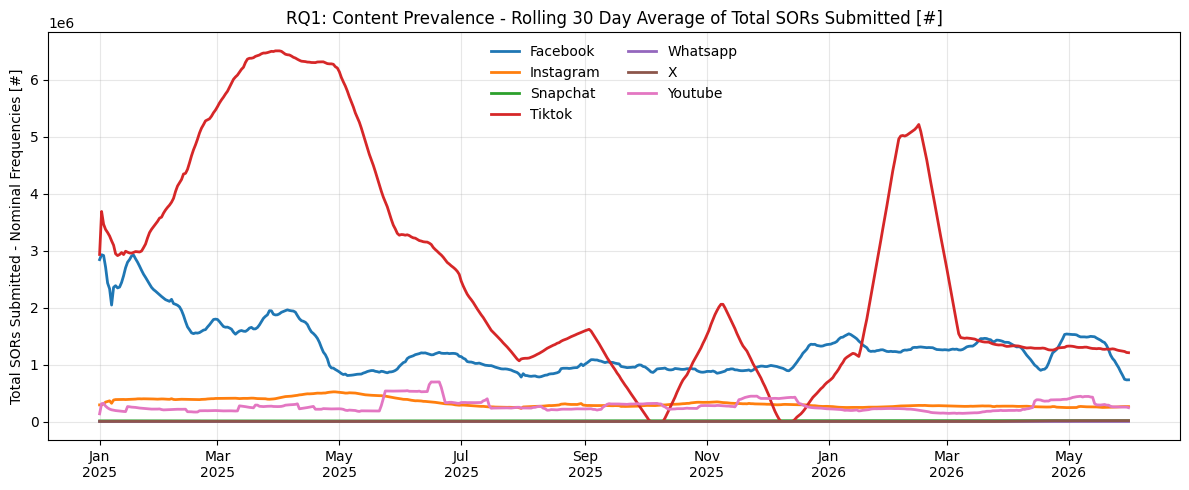

In [25]:
### Total Moderation
#### Nominal Amounts of Total SORs
fig, ax = plt.subplots(figsize=(12,5))

for platform, d in df_time.groupby("platform"):
  ax.plot(d["date"], d["roll_all"],
          linewidth=2, label=platform)

ax.set_xlabel("")
ax.set_ylabel("Total SORs Submitted - Nominal Frequencies [#]")
ax.set_title("RQ1: Content Prevalence - Rolling 30 Day Average of Total SORs Submitted [#]")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.legend(frameon=False, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(f"{path_out}03_rq1_8_30day_roll_nominal_all_sors.pdf",
            format="pdf", dpi=300, bbox_inches="tight")

In [ ]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Peaks and Troughs Assessment ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
### Find Quantiles of Synthetic Media Rel to Total
quants = (df_time.groupby("platform")["syn_rel_to_total_perc"]
          .quantile([0.01, 0.1, 0.50, 0.90, 0.95, 0.99, 0.999])
          .unstack()).reset_index().round(2)

###### Export
quants.to_csv(f"{path_out}03_rq1_9_syn_rel_to_total_quantiles.csv")

#### Find Max Min
max_min = (df_time.groupby("platform")["syn_rel_to_total_perc"]
           .idxmax())

max_min = df_time.loc[max_min, ["platform","date","syn_rel_to_total_perc"]].reset_index(drop=True)
max_min["syn_rel_to_total_perc"] = max_min["syn_rel_to_total_perc"].round(2)

###### Export
max_min.to_csv(f"{path_out}03_rq1_10_syn_rel_to_total_max_min.csv")

#### Max Drawdown - Calculate
df_draw = df_time.copy()
df_draw["running_max"] = (df_draw.groupby("platform")["roll_syn_prev"]
                          .cummax())
df_draw["drawdown"] = (df_draw["roll_syn_prev"] - df_draw["running_max"])/df_draw["running_max"]
df_draw["drawdown"] = df_draw["drawdown"].fillna(0)

#### Max Drawdown - Maximum
max_drawdown = (df_draw.groupby("platform", as_index=False)
                .agg(max_drawdown=("drawdown","min")))

#### Convert to %
max_drawdown["max_drawdown"] = (max_drawdown["max_drawdown"]*100).round(2)

### Max Drawdown Date
idx = df_draw.groupby("platform")["drawdown"].idxmin()

drawdown_dates = (df_draw.loc[idx,["platform","date","roll_syn_prev","running_max","drawdown"]])

drawdown_dates = drawdown_dates[["platform", "date", "drawdown"]]
drawdown_dates["drawdown"] = (drawdown_dates["drawdown"]*100).round(2)
drawdown_dates.rename(columns={"drawdown":"max_drawdown"})

###### Export
drawdown_dates.to_csv(f"{path_out}03_rq1_11_syn_rel_to_total_drawdown.csv")